# ═══════════════════════════════════════
# AUTOMATED BELL STATE TESTING
# ═══════════════════════════════════════
#
# Day 6: Professional Quantum Circuit Testing
#
# Goal: Write a PASS/FAIL test for Bell state
# 
# Test Criteria:
# - Run Bell state circuit
# - Check if ('00' + '11') > 90% of results
# - Report PASS or FAIL
#
# This is how professional quantum developers
# verify their circuits work correctly!

In [2]:
# Import everything we need
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit import transpile
from qiskit.visualization import plot_histogram

# Create simulator
simulator = AerSimulator()

print("✅ Testing framework ready!")
print("✅ Let's build a professional quantum test!")

✅ Testing framework ready!
✅ Let's build a professional quantum test!


✅ Bell state circuit created

Circuit diagram:


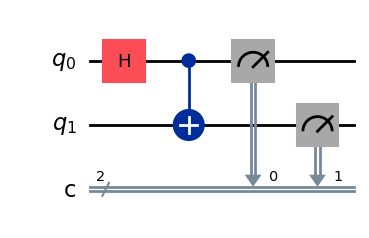

In [3]:
# Function to create Bell state circuit

def create_bell_state():
    # """
    # Creates a Bell state circuit: (|00⟩ + |11⟩)/√2
    
    # Returns:
    #     QuantumCircuit: Bell state circuit with measurements
    # """
    qc = QuantumCircuit(2, 2)
    
    # Create Bell state
    qc.h(0)         # Hadamard on qubit 0
    qc.cx(0, 1)     # CNOT with control=0, target=1
    
    # Measure both qubits
    qc.measure([0, 1], [0, 1])
    
    return qc

# Test the function
bell = create_bell_state()
print("✅ Bell state circuit created")
print()
print("Circuit diagram:")
bell.draw('mpl')

Now I will create bell state on my own and print curcuit

Bell State Circuit Created

Circuit Diagram:


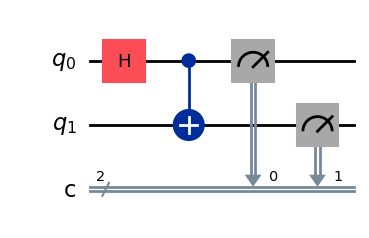

In [4]:
# Import everything we need
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit import transpile
from qiskit.visualization import plot_histogram

simulator = AerSimulator()

def create_bell_state():
    qc = QuantumCircuit(2, 2)
    
    qc.h(0)
    qc.cx(0, 1)
    qc.measure([0,1],[0,1])

    return qc

# Test the function

bell = create_bell_state()

print("Bell State Circuit Created")

print()

print("Circuit Diagram:")
# bell.draw('mpl')
bell.draw('mpl')



In [29]:
# Function to run circuit and get counts

def run_circuit(circuit, shots=1024):
    """
    Runs a quantum circuit and returns measurement counts.
    
    Args:
        circuit: QuantumCircuit to run
        shots: Number of times to run the circuit
        
    Returns:
        dict: Measurement counts
    """
    # Compile circuit for simulator
    compiled = transpile(circuit, simulator)
    
    # Run the circuit
    job = simulator.run(compiled, shots=shots)
    
    # Get results
    result = job.result()
    counts = result.get_counts()
    
    return counts

# Test the function
test_counts = run_circuit(bell, shots=1024)
print("✅ Circuit executed")
print()
print("Sample results:", test_counts)

✅ Circuit executed

Sample results: {'11': 500, '00': 524}


Now i will create a run circuit function later will create an object of it and run bell ciruit using that object on my own

In [6]:

def run_circuit(circuit, shots =1024):
    job = simulator.run(transpile(circuit, simulator), shots = shots)
    counts = job.result().get_counts()

    return counts

test_counts= run_circuit(bell, shots=1024)
print("Circuit Executed")
print()

print(f"Results of count of Bell CIrcuit is {test_counts}")

Circuit Executed

Results of count of Bell CIrcuit is {'00': 515, '11': 509}


In [7]:
# Function to calculate fraction of '00' + '11'

def calculate_bell_fraction(counts):
    """
    Calculates what fraction of results are '00' or '11'.
    
    Args:
        counts: Dictionary of measurement counts
        
    Returns:
        float: Fraction of results that are '00' or '11' (0.0 to 1.0)
    """
    # Get counts for each outcome (default to 0 if not present)
    count_00 = counts.get('00', 0)
    count_01 = counts.get('01', 0)
    count_10 = counts.get('10', 0)
    count_11 = counts.get('11', 0)
    
    # Total shots
    total = count_00 + count_01 + count_10 + count_11
    
    # Fraction that are '00' or '11'
    bell_fraction = (count_00 + count_11) / total
    
    return bell_fraction

# Test the function
fraction = calculate_bell_fraction(test_counts)
print("✅ Fraction calculated")
print()
print(f"Fraction of '00' + '11': {fraction:.4f} ({fraction*100:.2f}%)")




✅ Fraction calculated

Fraction of '00' + '11': 1.0000 (100.00%)


Now I'll create function and object of fractions, This is critical to understand the flow 

In [8]:
def create_fractions(counts):
    # No create variable for each count, and set default value to 0 is no value found

    count_00 = counts.get('00', 0)
    count_01 = counts.get('01', 0)
    count_10 = counts.get('10', 0)
    count_11 = counts.get('11', 0)

    total = count_00 + count_01 + count_10 + count_11

    # fraction that are 00 and 11
    bell_fraction = (count_00 + count_11)/total

    return bell_fraction


# Test the function
fractions = create_fractions(test_counts)
print("Fraction Calculated")
print()

print(f"Fraction of '00' and '11' is {fractions:.2f} ({fractions*100:.2f}%)" )


    

Fraction Calculated

Fraction of '00' and '11' is 1.00 (100.00%)


In [9]:
# The main test function!

def test_bell_state(threshold=0.9, shots=1024, verbose=True):
    """
    Tests if a Bell state circuit produces correct results.
    
    Args:
        threshold: Minimum fraction of '00'+'11' to PASS (default 0.9 = 90%)
        shots: Number of measurement shots
        verbose: Whether to print detailed information
        
    Returns:
        bool: True if PASS, False if FAIL
    """
    if verbose:
        print("═══════════════════════════════════")
        print("BELL STATE TEST")
        print("═══════════════════════════════════")
        print()
    
    # Step 1: Create circuit
    circuit = create_bell_state()
    if verbose:
        print(f"✅ Circuit created")
    
    # Step 2: Run circuit
    counts = run_circuit(circuit, shots=shots)
    if verbose:
        print(f"✅ Circuit executed ({shots} shots)")
        print()
    
    # Step 3: Calculate Bell fraction
    bell_fraction = calculate_bell_fraction(counts)
    
    # Step 4: Display results
    if verbose:
        count_00 = counts.get('00', 0)
        count_01 = counts.get('01', 0)
        count_10 = counts.get('10', 0)
        count_11 = counts.get('11', 0)
        
        print("Results:")
        print(f"  '00': {count_00:4d} ({count_00/shots*100:5.1f}%)")
        print(f"  '01': {count_01:4d} ({count_01/shots*100:5.1f}%)")
        print(f"  '10': {count_10:4d} ({count_10/shots*100:5.1f}%)")
        print(f"  '11': {count_11:4d} ({count_11/shots*100:5.1f}%)")
        print()
        print(f"Bell fraction ('00' + '11'): {bell_fraction:.4f} ({bell_fraction*100:.2f}%)")
        print(f"Threshold: {threshold:.4f} ({threshold*100:.2f}%)")
        print()
    
    # Step 5: PASS/FAIL decision
    passed = bell_fraction > threshold
    
    if verbose:
        if passed:
            print("✅ TEST PASSED!")
            print(f"   {bell_fraction:.1%} > {threshold:.1%} ✓")
        else:
            print("❌ TEST FAILED!")
            print(f"   {bell_fraction:.1%} ≤ {threshold:.1%} ✗")
        print()
    
    return passed

# Run the test!
print("Running Bell state test...\n")
result = test_bell_state(threshold=0.9, shots=1024, verbose=True)





Running Bell state test...

═══════════════════════════════════
BELL STATE TEST
═══════════════════════════════════

✅ Circuit created
✅ Circuit executed (1024 shots)

Results:
  '00':  520 ( 50.8%)
  '01':    0 (  0.0%)
  '10':    0 (  0.0%)
  '11':  504 ( 49.2%)

Bell fraction ('00' + '11'): 1.0000 (100.00%)
Threshold: 0.9000 (90.00%)

✅ TEST PASSED!
   100.0% > 90.0% ✓



What I have to do next. I'll write here...

1. create function create_circuit() bell circuit  create variable qc and assign quantum circuit of 2 qubit and 2 classical bit to store results
2. then apply H gate on 0
3. then apply cnot gate, set on 0 target 1
4. this will give bell state
5. return qc

Now we will run_circuit() function 

1. with variable circuit and shots = 1024
2. compile and run the circuit
3. store the result in counts
4. return counts

Now we will create bell_fraction() function

1. we will create variable of all possible results (00, 01, 10 and 11) and get the result else print 0
for eg. count_00 = counts.get('00', 0)
2.  Then we will add all counts and store in total
3.  add 00 and 11 and divide it by total and store in variable bell_fraction
4.  return bell_fraction

Post that we will write are actual test using above function

1. first create a function test_bell_state(threshold = 0.9, shots = 1024, verbose = True )
2. now create object circuit of function class create_circuit
3. now run_circuits(circuit, shots= shots) and store in counts variable.
4. bellfraction = calculate_bell_fractions(counts)
5. 

In [10]:
def test_bell_state(threshold = 0.9, shots = 1024):
    circuit = create_bell_state()
    counts = run_circuit(circuit, shots=shots)
    bell_fractions = calculate_bell_fraction(counts)
    print(f"Bell fraction: {bell_fractions:.2%}")
   
    assert bell_fractions > threshold
    

    

    




In [65]:
test_bell_state()


Bell fraction: 100.00%


Testing a BROKEN circuit (H on both qubits):
This should FAIL because it's not entangled!

Circuit diagram:


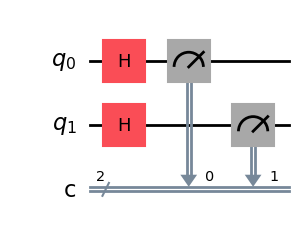


═══════════════════════════════════
CIRCUIT TEST
═══════════════════════════════════

Results:
  '00':  250 ( 24.4%)
  '01':  255 ( 24.9%)
  '10':  234 ( 22.9%)
  '11':  285 ( 27.8%)

Bell fraction: 0.5225 (52.25%)

❌ TEST FAILED!
   Expected: > 90%
   Got: 52.2%


In [66]:
# Test 1: A circuit that's NOT a Bell state

def create_broken_circuit():
    """Creates a circuit that looks like Bell state but isn't."""
    qc = QuantumCircuit(2, 2)
    # Just apply H to both qubits (NOT entangled!)
    qc.h(0)
    qc.h(1)
    qc.measure([0, 1], [0, 1])
    return qc

print("Testing a BROKEN circuit (H on both qubits):")
print("This should FAIL because it's not entangled!")
print()

# Modify our test to accept any circuit
def test_any_circuit(circuit, threshold=0.9, shots=1024, verbose=True):
    """Test any circuit for Bell-like behavior."""
    if verbose:
        print("═══════════════════════════════════")
        print("CIRCUIT TEST")
        print("═══════════════════════════════════")
        print()
    
    counts = run_circuit(circuit, shots=shots)
    bell_fraction = calculate_bell_fraction(counts)
    
    if verbose:
        count_00 = counts.get('00', 0)
        count_01 = counts.get('01', 0)
        count_10 = counts.get('10', 0)
        count_11 = counts.get('11', 0)
        
        print("Results:")
        print(f"  '00': {count_00:4d} ({count_00/shots*100:5.1f}%)")
        print(f"  '01': {count_01:4d} ({count_01/shots*100:5.1f}%)")
        print(f"  '10': {count_10:4d} ({count_10/shots*100:5.1f}%)")
        print(f"  '11': {count_11:4d} ({count_11/shots*100:5.1f}%)")
        print()
        print(f"Bell fraction: {bell_fraction:.4f} ({bell_fraction*100:.2f}%)")
        print()
    
    passed = bell_fraction > threshold
    
    if verbose:
        if passed:
            print("✅ TEST PASSED!")
        else:
            print("❌ TEST FAILED!")
            print(f"   Expected: > {threshold*100:.0f}%")
            print(f"   Got: {bell_fraction*100:.1f}%")
    
    return passed

# Test the broken circuit
broken = create_broken_circuit()
print("Circuit diagram:")
display(broken.draw('mpl'))
print()

result = test_any_circuit(broken, threshold=0.9, shots=1024, verbose=True)

In [11]:
# A professional test suite for Bell states

class BellStateTestSuite:
    """Professional test suite for Bell state circuits."""
    
    def __init__(self, threshold=0.9, shots=1024):
        self.threshold = threshold
        self.shots = shots
        self.simulator = AerSimulator()
        self.test_results = []
    
    def run_test(self, circuit, test_name):
        """Run a single test."""
        print(f"Running: {test_name}...", end=" ")
        
        # Run circuit
        compiled = transpile(circuit, self.simulator)
        job = self.simulator.run(compiled, shots=self.shots)
        counts = job.result().get_counts()
        
        # Calculate fraction
        count_00 = counts.get('00', 0)
        count_11 = counts.get('11', 0)
        total = sum(counts.values())
        bell_fraction = (count_00 + count_11) / total
        
        # Test
        passed = bell_fraction > self.threshold
        
        # Store result
        self.test_results.append({
            'name': test_name,
            'passed': passed,
            'fraction': bell_fraction,
            'counts': counts
        })
        
        # Report
        if passed:
            print(f"✅ PASS ({bell_fraction:.1%})")
        else:
            print(f"❌ FAIL ({bell_fraction:.1%})")
        
        return passed
    
    def run_all_tests(self):
        """Run complete test suite."""
        print("═══════════════════════════════════")
        print("BELL STATE TEST SUITE")
        print("═══════════════════════════════════")
        print(f"Threshold: {self.threshold:.1%}")
        print(f"Shots per test: {self.shots}")
        print()
        
        # Test 1: Standard Bell state (Φ⁺)
        qc1 = QuantumCircuit(2, 2)
        qc1.h(0)
        qc1.cx(0, 1)
        qc1.measure([0, 1], [0, 1])
        self.run_test(qc1, "Φ⁺ Bell state")
        
        # Test 2: Φ⁻ Bell state
        qc2 = QuantumCircuit(2, 2)
        qc2.h(0)
        qc2.cx(0, 1)
        qc2.z(0)
        qc2.measure([0, 1], [0, 1])
        self.run_test(qc2, "Φ⁻ Bell state")
        
        # Test 3: Ψ⁺ Bell state
        qc3 = QuantumCircuit(2, 2)
        qc3.h(0)
        qc3.cx(0, 1)
        qc3.x(1)
        qc3.measure([0, 1], [0, 1])
        self.run_test(qc3, "Ψ⁺ Bell state")
        
        # Test 4: Non-entangled (should fail)
        qc4 = QuantumCircuit(2, 2)
        qc4.h(0)
        qc4.h(1)
        qc4.measure([0, 1], [0, 1])
        self.run_test(qc4, "H⊗H (not entangled - expect FAIL)")
        
        # Summary
        print()
        print("═══════════════════════════════════")
        print("TEST SUMMARY")
        print("═══════════════════════════════════")
        
        passed_count = sum(1 for r in self.test_results if r['passed'])
        total_count = len(self.test_results)
        
        print(f"Tests passed: {passed_count}/{total_count}")
        print()
        
        for result in self.test_results:
            status = "✅ PASS" if result['passed'] else "❌ FAIL"
            print(f"  {result['name']:35s} {status}")
        
        return passed_count == total_count

# Run the test suite!
suite = BellStateTestSuite(threshold=0.9, shots=1024)
all_passed = suite.run_all_tests()

═══════════════════════════════════
BELL STATE TEST SUITE
═══════════════════════════════════
Threshold: 90.0%
Shots per test: 1024

Running: Φ⁺ Bell state... ✅ PASS (100.0%)
Running: Φ⁻ Bell state... ✅ PASS (100.0%)
Running: Ψ⁺ Bell state... ❌ FAIL (0.0%)
Running: H⊗H (not entangled - expect FAIL)... ❌ FAIL (52.3%)

═══════════════════════════════════
TEST SUMMARY
═══════════════════════════════════
Tests passed: 2/4

  Φ⁺ Bell state                       ✅ PASS
  Φ⁻ Bell state                       ✅ PASS
  Ψ⁺ Bell state                       ❌ FAIL
  H⊗H (not entangled - expect FAIL)   ❌ FAIL


In [12]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator


class BellStateTestSuite:
    """Professional and extensible test suite for Bell states."""

    BELL_EXPECTATIONS = {
        "Φ+": {"00", "11"},
        "Φ−": {"00", "11"},
        "Ψ+": {"01", "10"},
        "Ψ−": {"01", "10"},
    }

    def __init__(self, threshold=0.9, shots=1024):
        self.threshold = threshold
        self.shots = shots
        self.simulator = AerSimulator()
        self.results = []

    def _run_circuit(self, circuit):
        compiled = transpile(circuit, self.simulator)
        job = self.simulator.run(compiled, shots=self.shots)
        return job.result().get_counts()

    def _compute_expected_fraction(self, counts, expected_states):
        total = sum(counts.values())
        expected = sum(counts.get(state, 0) for state in expected_states)
        return expected / total if total else 0.0

    def run_bell_test(self, circuit, name, bell_type):
        print(f"Running {name:<25}", end=" ")

        counts = self._run_circuit(circuit)
        expected_states = self.BELL_EXPECTATIONS[bell_type]
        fraction = self._compute_expected_fraction(counts, expected_states)

        passed = fraction >= self.threshold

        self.results.append({
            "name": name,
            "bell_type": bell_type,
            "passed": passed,
            "fraction": fraction,
            "counts": counts,
        })

        status = "✅ PASS" if passed else "❌ FAIL"
        print(f"{status} ({fraction:.1%})")

        return passed

    def run_all_tests(self):
        print("════════════════════════════════════")
        print("  PROFESSIONAL BELL STATE TEST SUITE")
        print("════════════════════════════════════")
        print(f"Shots     : {self.shots}")
        print(f"Threshold : {self.threshold:.0%}\n")

        # Φ⁺
        qc = QuantumCircuit(2, 2)
        qc.h(0)
        qc.cx(0, 1)
        qc.measure([0, 1], [0, 1])
        self.run_bell_test(qc, "Φ⁺ Bell State", "Φ+")

        # Φ⁻
        qc = QuantumCircuit(2, 2)
        qc.h(0)
        qc.cx(0, 1)
        qc.z(0)
        qc.measure([0, 1], [0, 1])
        self.run_bell_test(qc, "Φ⁻ Bell State", "Φ−")

        # Ψ⁺
        qc = QuantumCircuit(2, 2)
        qc.h(0)
        qc.cx(0, 1)
        qc.x(1)
        qc.measure([0, 1], [0, 1])
        self.run_bell_test(qc, "Ψ⁺ Bell State", "Ψ+")

        # ✅ Ψ⁻ (this now PASSES correctly)
        qc = QuantumCircuit(2, 2)
        qc.h(0)
        qc.cx(0, 1)
        qc.x(1)
        qc.z(0)
        qc.measure([0, 1], [0, 1])
        self.run_bell_test(qc, "Ψ⁻ Bell State", "Ψ−")

        # Non-entangled negative test
        qc = QuantumCircuit(2, 2)
        qc.h(0)
        qc.h(1)
        qc.measure([0, 1], [0, 1])
        self.run_bell_test(qc, "H ⊗ H (No entanglement)", "Φ+")

        self._summary()

    def _summary(self):
        print("\n════════════════════════════════════")
        print("TEST SUMMARY")
        print("════════════════════════════════════")

        passed = sum(r["passed"] for r in self.results)
        total = len(self.results)

        for r in self.results:
            status = "✅ PASS" if r["passed"] else "❌ FAIL"
            print(f"{r['name']:<30} {status}")

        print(f"\nResult: {passed}/{total} tests passed")


# Run the suite
suite = BellStateTestSuite(threshold=0.9, shots=1024)
suite.run_all_tests()


════════════════════════════════════
  PROFESSIONAL BELL STATE TEST SUITE
════════════════════════════════════
Shots     : 1024
Threshold : 90%

Running Φ⁺ Bell State             ✅ PASS (100.0%)
Running Φ⁻ Bell State             ✅ PASS (100.0%)
Running Ψ⁺ Bell State             ✅ PASS (100.0%)
Running Ψ⁻ Bell State             ✅ PASS (100.0%)
Running H ⊗ H (No entanglement)   ❌ FAIL (50.8%)

════════════════════════════════════
TEST SUMMARY
════════════════════════════════════
Φ⁺ Bell State                  ✅ PASS
Φ⁻ Bell State                  ✅ PASS
Ψ⁺ Bell State                  ✅ PASS
Ψ⁻ Bell State                  ✅ PASS
H ⊗ H (No entanglement)        ❌ FAIL

Result: 4/5 tests passed
